In [1]:
import os
import concurrent.futures
import numpy as np
import jax
import pybamm
from scipy.stats import qmc
# Configure JAX to use the CPU with 48 threads.
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".70"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["OMP_NUM_THREADS"] = "40"
#os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen_thread_count=48"

# -------------------------------
# Sobol Sequence for SOC and Diffusivities
# -------------------------------
# def get_soc_and_diffusivities_sobol(
#     soc_levels,
#     num_samples_per_soc,
#     log_lower=-14,
#     log_upper=-12
# ):
#     """
#     Generates diffusivities (D1, D2) in log10 space for each SOC level,
#     ensuring each SOC gets a distinct chunk of the Sobol sequence.
    
#     Returns an array of shape (len(soc_levels)*num_samples_per_soc, 3),
#     with columns [SOC, D1, D2].
#     """
#     sampler_log = qmc.Sobol(d=2, scramble=True)
#     n_soc = len(soc_levels)
#     total_samples = n_soc * num_samples_per_soc
#     results = np.zeros((total_samples, 3), dtype=float)
#     idx = 0
#     for i, soc in enumerate(soc_levels):
#         skip_from = (i+1) * num_samples_per_soc
#         sampler_log.reset()
#         sampler_log.fast_forward(skip_from)
#         samples_unit = sampler_log.random(num_samples_per_soc)
#         samples_log = qmc.scale(samples_unit, log_lower, log_upper)
#         for row in range(num_samples_per_soc):
#             results[idx, 0] = soc
#             results[idx, 1] = samples_log[row, 0]  # log10(Dan)
#             results[idx, 2] = samples_log[row, 1]  # log10(Dca)
#             idx += 1
#     return results

# -------------------------------
# PyBaMM Setup and Helper Functions
# -------------------------------

# Create the SPM model and remove events if needed
spm = pybamm.lithium_ion.SPM()
spm.events = []

# Global battery parameters and time discretization:
params_bat = pybamm.ParameterValues("Chen2020")
C = params_bat["Nominal cell capacity [A.h]"]
t_max = 3600
t_sim = 900
points_per_segment = 75
num_segments = int(t_max / t_sim)
num_samples_I = points_per_segment * num_segments
num_samples_c0 = 20
t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

def get_targets(I_samples, soc=0.5): #, Dan=3.3e-14, Dca=4.0e-15):
    """
    For each current function in I_samples, set the battery parameters,
    run the simulation, and extract the target and initial concentrations.
    """
    set_targets_anode = []
    set_targets_cathode = []
    set_c0_anode = []
    set_c0_cathode = []
    set_currents = []
    
    for I_func in I_samples:
        params_local = pybamm.ParameterValues("Chen2020")
        params_local["Current function [A]"] = pybamm.Interpolant(t, -1. * I_func, pybamm.t)
        # params_local["Negative particle diffusivity [m2.s-1]"] = Dan
        # params_local["Positive particle diffusivity [m2.s-1]"] = Dca
        sim = pybamm.Simulation(spm, parameter_values=params_local)
        sol = sim.solve(initial_soc=soc, t_eval=t)
        
        # c0_anode = sol["Negative particle concentration"].entries[:, 0, 0]
        # cn_target_anode = sol["Negative particle concentration"].entries[:, 0, :]
        # c0_cathode = sol["Positive particle concentration"].entries[:, 0, 0]
        # cn_target_cathode = sol["Positive particle concentration"].entries[:, 0, :]

        for seg in range(num_segments):
                start = seg * points_per_segment
                end = (seg + 1) * points_per_segment

                seg_c0_anode = sol["Negative particle concentration"].entries[:, 0, start]
                seg_cn_target_anode = sol["Negative particle concentration"].entries[:, 0, start:end]
                seg_c0_cathode = sol["Positive particle concentration"].entries[:, 0, start]
                seg_cn_target_cathode = sol["Positive particle concentration"].entries[:, 0, start:end]
                seg_current = I_func[start:end]

                set_targets_anode.append(seg_cn_target_anode)
                set_c0_anode.append(seg_c0_anode)
                set_targets_cathode.append(seg_cn_target_cathode)
                set_c0_cathode.append(seg_c0_cathode)
                set_currents.append(seg_current)

        
        # set_targets_anode.append(cn_target_anode)
        # set_c0_anode.append(c0_anode)
        # set_targets_cathode.append(cn_target_cathode)
        # set_c0_cathode.append(c0_cathode)
        # set_currents.append(I_func)
    
    return (set_targets_anode, set_c0_anode,
            set_targets_cathode, set_c0_cathode,
            set_currents)

# -------------------------------
# Data Generation Functions (no JAX)
# -------------------------------

# We assume a module named "functions" provides our current functions.
# For our example, we assume the above definitions are used.
import functions  # Ensure this module is in your PYTHONPATH

def generate_data(seed, num, family="CC"):
    """
    Generate a list of current profiles using NumPy for random numbers.
    
    The seed is used to ensure reproducibility.
    """
    np.random.seed(seed)
    I_list = []
    if family == "GRF":
        for _ in range(num):
            s = np.random.randint(0, 2**31 - 1)
            I_func = functions.GaussianRFCurrent(s, C, t_max)
            I_list.append(I_func(t))
    elif family == "Triangle":
        for _ in range(num):
            value = np.random.uniform(-1, 1)
            I_func = functions.TriangleCurrent(value * C)
            I_list.append(I_func(t))
    elif family == "CC":
        for _ in range(num):
            value = np.random.uniform(-1, 1)
            I_func = functions.ConstantCurrent(value * C)
            I_list.append(I_func(t))
    return I_list

# -------------------------------
# Parallel Simulation Worker & Aggregator (no JAX)
# -------------------------------

def simulate_worker(args):
    """
    Worker function to run one simulation instance for a given SOC and log-diffusivity pair.
    
    args: tuple containing:
         i          : iteration index (used for seed adjustment)
         soc        : SOC value for this run
         Dan_log    : log10 value for the negative diffusivity
         Dca_log    : log10 value for the positive diffusivity
         seed_train : base seed for training data generation
         seed_test  : base seed for test data generation
         num_train  : number of training current profiles
         num_test   : number of test current profiles
         family     : current profile family ("CC", "GRF", or "Triangle")
    """
    i, soc, seed_train, seed_test, num_train, num_test, family = args
    print(f"Worker {i}: SOC={soc}") #, Dan_log={Dan_log}, Dca_log={Dca_log}")
    
    # Create unique seeds for this worker by offsetting the base seeds.
    train_seed = seed_train + i
    test_seed  = seed_test + i
    
    # # Convert log diffusivities to actual values.
    # Dan = 10 ** Dan_log
    # Dca = 10 ** Dca_log
    
    # Generate current profiles for training and test.
    train_I = generate_data(train_seed, num_train, family=family)
    test_I = generate_data(test_seed, num_test, family=family)
    
    try:
        # Obtain target and initial concentration profiles.
        train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode, train_I2 = get_targets(
            train_I, soc=soc #, Dan=Dan, Dca=Dca
        )
        test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode, test_I2 = get_targets(
            test_I, soc=soc #, Dan=Dan, Dca=Dca
        )
    except pybamm.SolverError as e:
        print(f"Simulation failed for worker {i}. Skipping.")
        return None
    
    return (
        train_I2, test_I2,
        train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode,
        test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode
    )

def process_family(family, soc_levels, seed_train, seed_test, num_train, num_test):
    """
    For a given family, run simulations in parallel for each (SOC, diffusivity) combination.
    
    Parameters:
       family            : current profile family ("CC", "GRF", "Triangle")
       soc_levels        : list of SOC values (used for labeling)
       diffusivity_params: array of shape (n, 3) with columns [SOC, Dan_log, Dca_log]
       seed_train, seed_test : integer seeds for data generation
       num_train, num_test   : number of current profiles to generate per simulation.
    """
    list_train_current = []
    list_test_current = []
    list_train_cn_anode = []
    list_train_cn_cathode = []
    list_train_c0_anode = []
    list_train_c0_cathode = []
    list_test_cn_anode = []
    list_test_cn_cathode = []
    list_test_c0_anode = []
    list_test_c0_cathode = []

    tasks = []
    for i, soc in enumerate(soc_levels):
        tasks.append((i, soc, seed_train, seed_test, num_train, num_test, family))
    
    with concurrent.futures.ProcessPoolExecutor() as executor:
        futures = [executor.submit(simulate_worker, task) for task in tasks]
        for future in concurrent.futures.as_completed(futures):
            result = future.result()
            if result is None:
                continue
            (train_I2, test_I2,
             train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode,
             test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode) = result

            list_train_current.extend(train_I2)
            list_test_current.extend(test_I2)
            list_train_cn_anode.extend(train_cn_anode)
            list_train_cn_cathode.extend(train_cn_cathode)
            list_train_c0_anode.extend(train_c0_anode)
            list_train_c0_cathode.extend(train_c0_cathode)
            list_test_cn_anode.extend(test_cn_anode)
            list_test_cn_cathode.extend(test_cn_cathode)
            list_test_c0_anode.extend(test_c0_anode)
            list_test_c0_cathode.extend(test_c0_cathode)

    train_I = np.array(list_train_current)
    test_I = np.array(list_test_current)
    train_cn_anode = np.array(list_train_cn_anode)
    test_cn_anode = np.array(list_test_cn_anode)
    train_c0_anode = np.array(list_train_c0_anode)
    test_c0_anode = np.array(list_test_c0_anode)
    train_cn_cathode = np.array(list_train_cn_cathode)
    test_cn_cathode = np.array(list_test_cn_cathode)
    train_c0_cathode = np.array(list_train_c0_cathode)
    test_c0_cathode = np.array(list_test_c0_cathode)

    path = "data/spm/for_soc/"
    train_filename = f"{path}train/{family}_{num_train * len(soc_levels)}.npz"
    test_filename = f"{path}test/{family}_{num_test * len(soc_levels)}.npz"
    np.savez(
        train_filename,
        current=train_I,
        initial_concentration_anode=train_c0_anode,
        target_concentration_anode=train_cn_anode,
        initial_concentration_cathode=train_c0_cathode,
        target_concentration_cathode=train_cn_cathode,
        soc=soc_levels
    )
    np.savez(
        test_filename,
        current=test_I,
        initial_concentration_anode=test_c0_anode,
        target_concentration_anode=test_cn_anode,
        initial_concentration_cathode=test_c0_cathode,
        target_concentration_cathode=test_cn_cathode,
        soc=soc_levels
    )
    print(f"Saved train data to {train_filename} and test data to {test_filename}")

# -------------------------------
# Main Script
# -------------------------------

if __name__ == "__main__":
    soc_levels = [0., 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.]
    families = ["GRF", "Triangle", "CC"]
    samples_per_soc = 1

    # diffusivity_params = get_soc_and_diffusivities_sobol(soc_levels, samples_per_soc, log_lower=-15, log_upper=-12)
    
    seed_train = 0
    seed_test = 4200

    num_train = 2000
    num_test = 200

    for family in families:
        print(f"Processing family: {family}")
        process_family(family, soc_levels, seed_train, seed_test, num_train, num_test)

Processing family: GRF
Worker 0: SOC=0.0Worker 2: SOC=0.2Worker 1: SOC=0.1Worker 3: SOC=0.3Worker 5: SOC=0.5
Worker 7: SOC=0.7Worker 6: SOC=0.6Worker 4: SOC=0.4
Worker 9: SOC=0.9
Worker 8: SOC=0.8Worker 10: SOC=1.0







Saved train data to data/spm/for_soc/train/GRF_22000.npz and test data to data/spm/for_soc/test/GRF_2200.npz
Processing family: Triangle
Worker 0: SOC=0.0Worker 2: SOC=0.2Worker 5: SOC=0.5Worker 3: SOC=0.3Worker 1: SOC=0.1Worker 4: SOC=0.4Worker 6: SOC=0.6Worker 7: SOC=0.7Worker 9: SOC=0.9Worker 8: SOC=0.8Worker 10: SOC=1.0










Saved train data to data/spm/for_soc/train/Triangle_22000.npz and test data to data/spm/for_soc/test/Triangle_2200.npz
Processing family: CC
Worker 1: SOC=0.1Worker 3: SOC=0.3Worker 2: SOC=0.2Worker 0: SOC=0.0Worker 4: SOC=0.4Worker 5: SOC=0.5Worker 7: SOC=0.7Worker 6: SOC=0.6Worker 8: SOC=0.8Worker 10: SOC=1.0Worker 9: SOC=0.9










Saved train data to data/spm/for_soc/train/CC_22000.npz and test data to data/spm/for_soc/test/CC_2200

In [2]:
path = "data/spm/implicit_D/"
family = "GRF"
train_filename = f"{path}train/{family}_{num_train * len(soc_levels)}.npz"
train_data = np.load(train_filename)


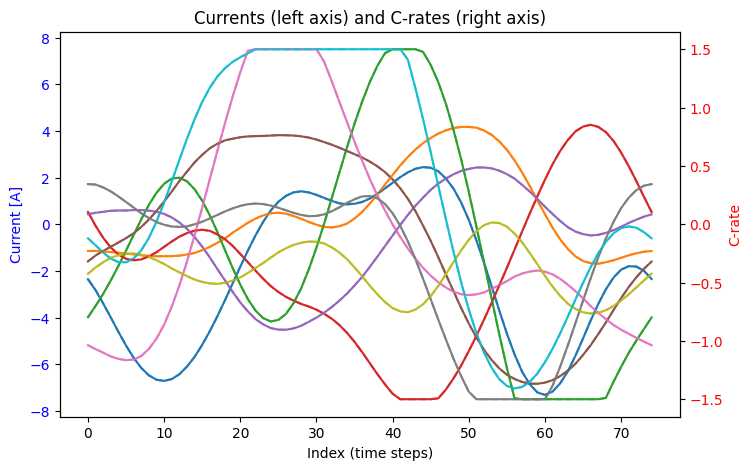

In [3]:
import matplotlib.pyplot as plt

# Suppose train_data["current"] is a numpy array of shape (14, 75),
# and we have some known battery capacity in ampere-hours, e.g. C = 5.0
data = train_data["current"]

# Create a figure with one Axes, then a twin Axes for second scale
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the currents on ax1
for i in range(10):
    ax1.plot(data[i, :], label=f"Series {i}")

ax1.set_xlabel("Index (time steps)")
ax1.set_ylabel("Current [A]", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Create second y‐axis for the C‐rate
ax2 = ax1.twinx()
for i in range(10):
    # Convert current [A] into C‐rate by dividing by capacity [Ah]
    # (If your capacity is in different units, adjust accordingly)
    c_rate = data[i, :] / C
    ax2.plot(c_rate, linestyle="--", alpha=0.7)

ax2.set_ylabel("C-rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Currents (left axis) and C-rates (right axis)")
plt.show()
